Problem 1)

a. Is the decision boundary of voted perceptron linear?

Answer: 

Voted perceptron first measures the prediction per weight and then calculates the weighted average of predictions. 

$\theta(x)=\frac{w_1^T \cdot X(t_2 - t_1) + w_2^T \cdot X(t_3 - t_2) + \dots + W_m^T \cdot X(t_m - t_{m-1})}{t_m}$

According to the above formula, the decision boundary of voted perceptron is linear.

b. Is the decision boundary of averaged perceptron linear?

Averaged perceptron measures the weighted average of all weights based on their duration.

$\theta(x)=\frac{w_1(t_2 - t_1) + w_2(t_3 - t_2) + \dots + W_m(t_m - t_{m-1})}{t_m}$

According to the above formula, the decision boundary of weighted perceptron is linear.

################################################################################################################################################################################################

Problem 2)

In the class, we saw the Passive-Aggressive (PA) update that tries to achieve a margin equal to *one* after each update. Derive the PA weight update for achieving margin $M$.

Answer:

Generally, perceptron doesn't guarantee that $margin(X,Y,w) >= 1$. To have this guarantee, Passive Aggressive algorithm is designed so that the $w$ it produces is guaranteed to have margin >= 1. This algorithm has two parts: Passive, when the $yw^T \cdot X > 1$. In this case, the predicted and actual values are equal with their signs. Aggressive: If $yw^T \cdot X < 1$, it means that the prediction and actual values have opposite signs. 

$w_* = (w + 2\alpha y \cdot x)$ if $(yw^T \cdot x) < 1$

$margin(w_*, x, y) >= M$

$yw_*^T \cdot x = y(w + 2\alpha y \cdot x)^T \cdot x >= M$

$yw^T \cdot x + 2\alpha ||x||^2 >= M$

$\frac{M - yw^T \cdot x}{2||x||^2} <= \alpha$

################################################################################################################################################################################################

Problem 3)

Consider the following setting. You are provided with n training examples: $(x_1, y_1, h_1), (x_2, y_2, h_2),\dots, (x_n, y_n, h_n)$, where $x_i$ is the input example, $y_i$ is the class label (+1 or -1), and $h_i>0$ is the importance weight of the example.

a. How will you modify the perceptron algorithm to be able to leverage this extra information? Please justify your answer.

Answer:

Conventionally, the update rule in perceptron is $w_i \leftarrow w_i + \alpha.(y_i - \theta (x)).x_i$. If a misprediction happens, the learning rule updates the weight towards to minimizing the error in an iterative manner. In this case, we can use $h_i$ as an accelerator to reach the minimum error by adding this parameter into the formula:

$w_i \leftarrow w_i + \alpha.h_i.(y_i - \theta (x)).x_i$

Intuitively, $h_i$ means having $h_i$ number of the example $(x_i, y_i)$.

b. How will you augment the dataset to solve this learning problem w/o modifying the standard perceptron algorithm? Please justify your answer.

Answer:

As I explained above, we can duplicate each example by $h_i$ times. This way, we can use the conventional update rule: $w_i \leftarrow w_i + \alpha.(y_i - \theta (x)).x_i$. The impact will be only on the convergence time.

################################################################################################################################################################################################

Problem 4)

Consider the following setting. You are provided with n training examples:
$(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$, where $x_i$ is the input example, and $y_i$ is the class label (+1 or -1).
However, the training data is highly imbalanced (say 90% of the examples are negative and 10% of the examples are positive) and we care more about the accuracy of positive examples.

$\textbf{(Note: I first answered the second part, then moved back to the first)}$

a. How will you modify the perceptron algorithm to solve this learning problem? Please justify your answer.

Answer:
We must tweak the update rule by adding a weight factor to the majoriy class data samples:

$W_i \leftarrow W_i + \alpha \cdot \gamma(Y_i) \cdot(Y_i - \theta(X_i)) \cdot X_i$

The weight factor $\gamma(Y_i)$ is a constant value based on the sample data belongs to either majority or minority class.

b. How will you augment the dataset to solve this learning problem w/o modifying the standard perceptron algorithm? Please justify your answer.

Answer: 

The less hassle workaround would be to resample the dataset. If that is not the case, one approach would be downsampling and upweighing. 
(Note, I learnt this technique from https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets , so my answer is based on what I learnt from this tutorial)
The approach is to reduce the the majority class samples by factor X, and increase the weight of this class by the factor of X. In this situtaion, if the model mispredicts the majority class sample, the error reflects the X times worse than the case where we have all samples of the majority class. 

################################################################################################################################################################################################

Problem 5)

5.1) Binary Classification


For standard perceptron, you will use $\tau = 1$, and for Passive-Aggressive (PA) algorithm, you will compute the learning rate $\tau$ as follows

$$
\tau = \frac{1- y_t \cdot (\omega \cdot x_t)}{||x_t||^2}
$$


In [5]:

! git clone https://github.com/zalandoresearch/fashion-mnist.git

Cloning into 'fashion-mnist'...
remote: Enumerating objects: 762, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 762 (delta 0), reused 0 (delta 0), pack-reused 760 (from 2)
Receiving objects: 100% (762/762), 105.85 MiB | 2.05 MiB/s, done.
Resolving deltas: 100% (444/444), done.


## Load training and eval data

This part is done with the help of fashion-mnist convert.py file and a little bit of Gemini to read the .gz file 

In [1]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import os
import gzip
import numpy as np
import tensorflow as tf
from sklearn.utils import shuffle

DATA_DIR = './fashion-mnist/data/fashion'

# Functions to load IDX formatted images and labels from gzip files
def load_idx_images(filepath):
    with gzip.open(filepath, 'r') as f:
        # Magic number, number of images, rows, cols
        _ = int.from_bytes(f.read(4), 'big')
        num_images = int.from_bytes(f.read(4), 'big')
        rows = int.from_bytes(f.read(4), 'big')
        cols = int.from_bytes(f.read(4), 'big')
        buf = f.read()
        data = np.frombuffer(buf, dtype=np.uint8)
        return data.reshape(num_images, rows * cols).astype(np.float32) / 255.0

def load_idx_labels(filepath):
    with gzip.open(filepath, 'r') as f:
        _ = int.from_bytes(f.read(4), 'big')
        num_labels = int.from_bytes(f.read(4), 'big')
        buf = f.read()
        return np.frombuffer(buf, dtype=np.uint8).astype(np.int32)

train_data = load_idx_images(os.path.join(DATA_DIR, 'train-images-idx3-ubyte.gz'))
train_labels = load_idx_labels(os.path.join(DATA_DIR, 'train-labels-idx1-ubyte.gz'))
train_data, train_labels = shuffle(train_data, train_labels)

eval_data = load_idx_images(os.path.join(DATA_DIR, 't10k-images-idx3-ubyte.gz'))
eval_labels = load_idx_labels(os.path.join(DATA_DIR, 't10k-labels-idx1-ubyte.gz'))
eval_data, eval_labels = shuffle(eval_data, eval_labels)

/Users/ben/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Train the binary classification model using Perceptron

In [30]:
# 1- Initialize the weight matrix
w = np.zeros(train_data[0].shape[0], dtype=np.float32)

T = 100  # Number of iterations for the main loop
perceptron_mistakes = {}

def return_label(label: int) -> int:
    return 1 if label % 2 != 0 else -1

# 2- main loop
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred != y_true:
            w += y_true * td
            if i not in perceptron_mistakes:
                perceptron_mistakes[i] = 0
            perceptron_mistakes[i] += 1

## Train the binary classification model using PA algorithm

In [ ]:
w_pa = np.zeros(train_data[0].shape[0], dtype=np.float32)

T = 100  # Number of iterations for the main loop
pa_mistakes = {}

def return_label(label: int) -> int:
    return 1 if label % 2 != 0 else -1

# 2- main loop
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w_pa, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred != y_true:
            tau = (1 - y_true * np.dot(w_pa, td)) / (2 * (np.linalg.norm(td) ** 2))
            w_pa += 2 * tau * y_true * td
            if i not in pa_mistakes:
                pa_mistakes[i] = 0
            pa_mistakes[i] += 1

## Plot the mistakes 

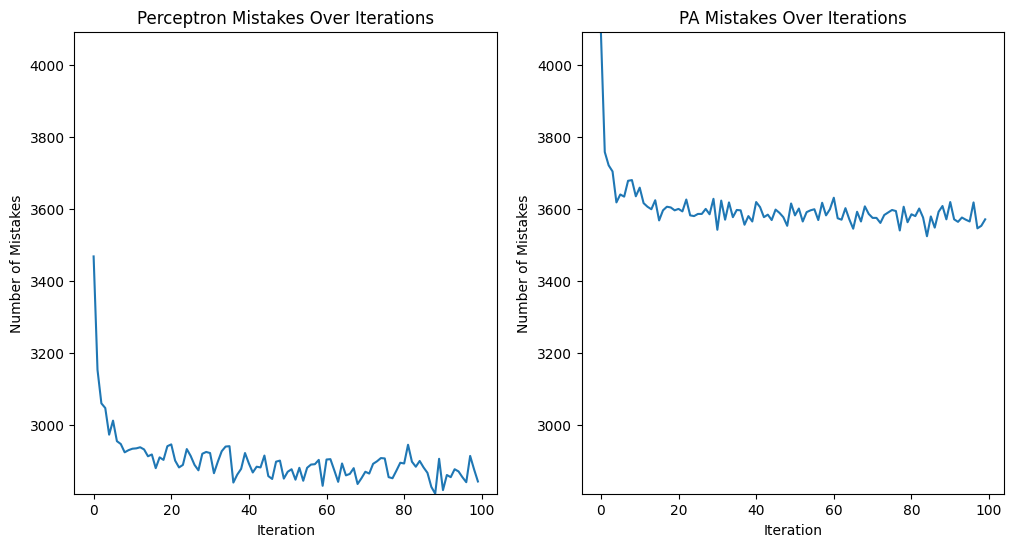

In [42]:
import matplotlib.pyplot as plt
%matplotlib inline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
max_y = max(list(perceptron_mistakes.values()) + list(pa_mistakes.values()))
min_y = min(list(perceptron_mistakes.values()) + list(pa_mistakes.values()))
ax1.plot(perceptron_mistakes.keys(), perceptron_mistakes.values())
ax1.set_ylim(min_y, max_y)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Number of Mistakes')
ax1.set_title('Perceptron Mistakes Over Iterations')

ax2.plot(pa_mistakes.keys(), pa_mistakes.values())
ax2.set_ylim(min_y, max_y)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Number of Mistakes')
ax2.set_title('PA Mistakes Over Iterations')

plt.show()

## Analysis


a) Both plots show that the mistakes converge to a certain value with some jitter. In addition, the mistakes after the convergence is lower in perceptron compared to PA, but neither of them reaches close to zero. And I think it makes sense because I did not run the training for long iterations. The noticable difference is that, the accuracy of perceptron is higher than that of PA algorithm, becasue the mistakes in perceptron converges at lower value than that of PA algorithm. And I beleive it is attributed to the learning rate of both approach. 

b) Accuracy analysis

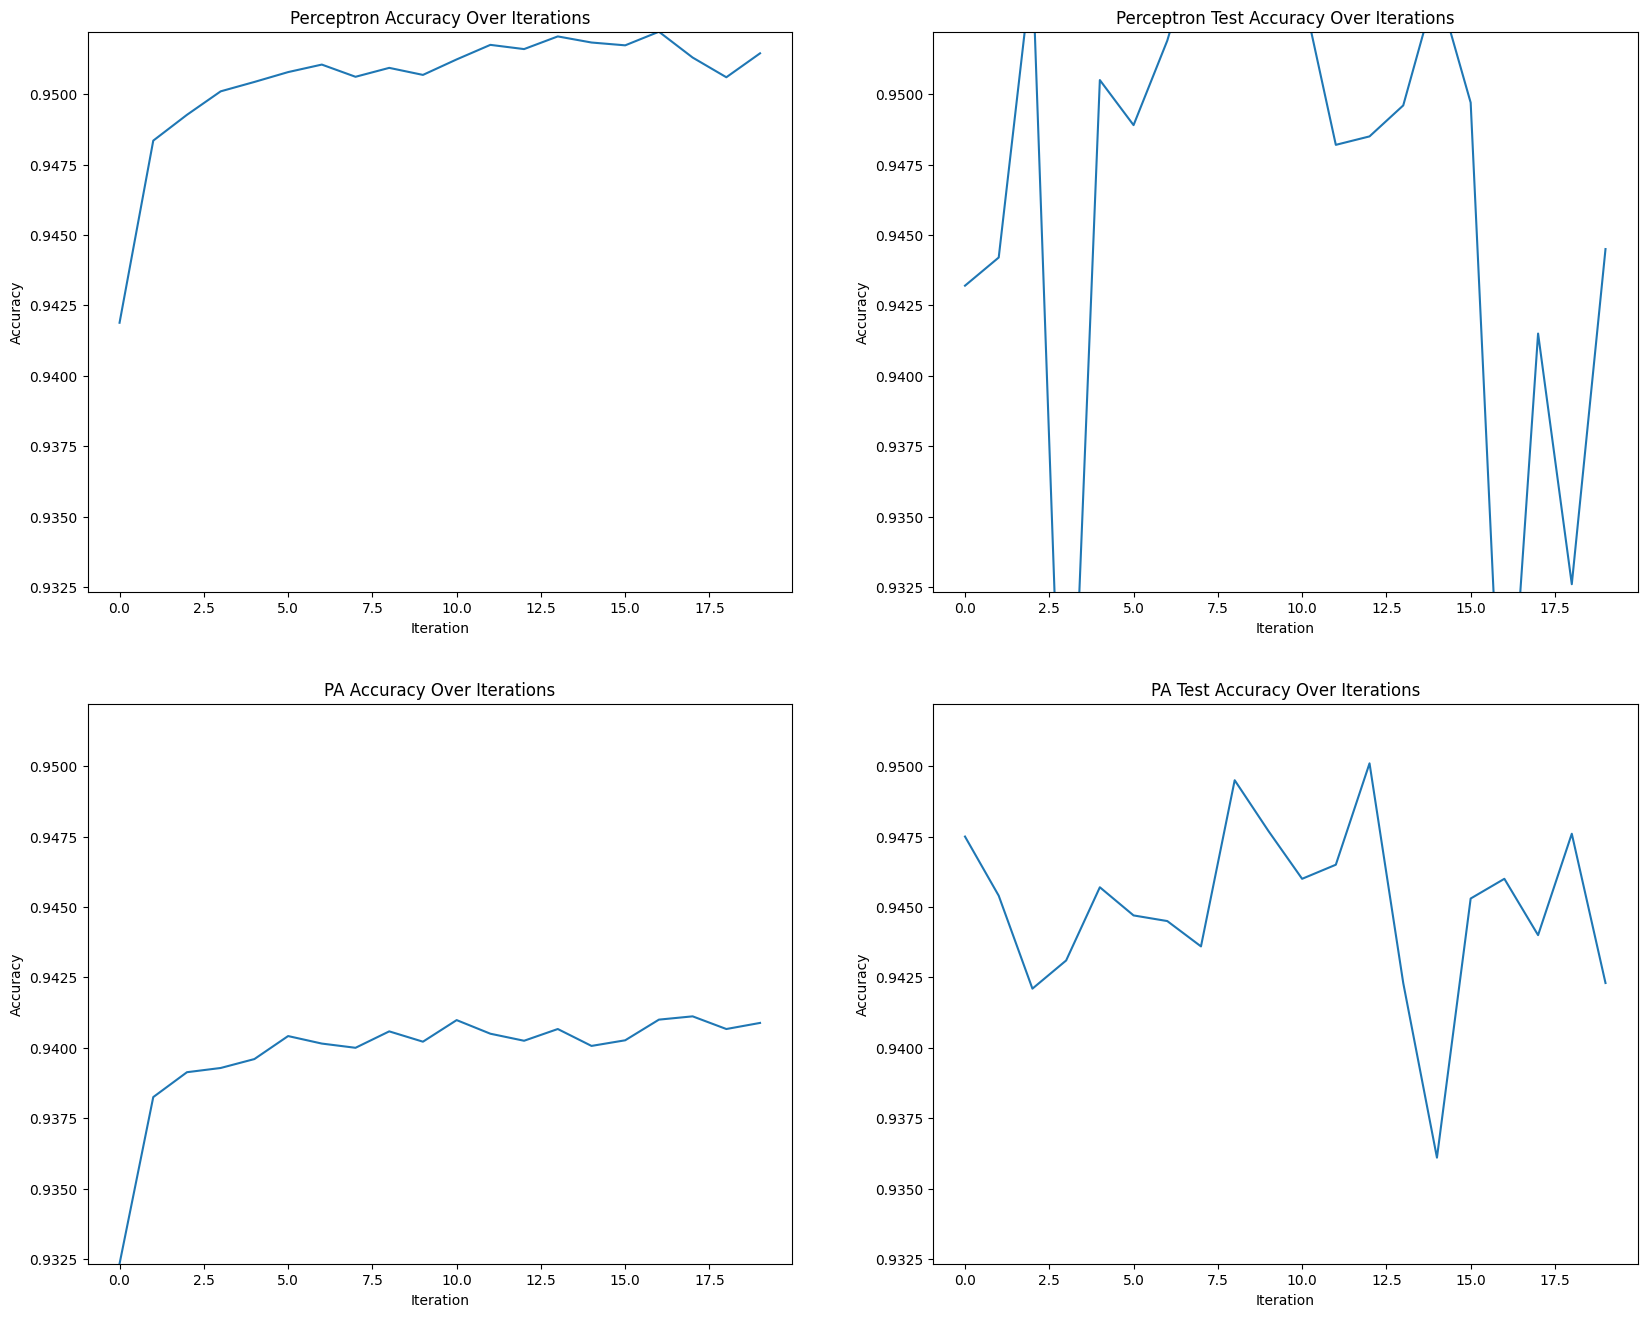

In [7]:
## Perceptron Algorithm Implementation
w = np.zeros(train_data[0].shape[0], dtype=np.float32)

T = 20  # Number of iterations for the main loop
perceptron_train_accuracy = {}
perceptron_test_accuracy = {}
def return_label(label: int) -> int:
    return 1 if label % 2 != 0 else -1

def test_accuracy(w):
    perceptron_test_accuracy = 0
    for td, tl in zip(eval_data, eval_labels):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred == y_true:
            perceptron_test_accuracy += 1
    return  perceptron_test_accuracy / len(eval_data)

# 2- main loop
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred != y_true:
            w += y_true * td
        else:
            if i not in perceptron_train_accuracy:
                perceptron_train_accuracy[i] = 0
            perceptron_train_accuracy[i] += 1
    perceptron_train_accuracy[i] = perceptron_train_accuracy[i] / len(train_data)
    perceptron_test_accuracy[i] = test_accuracy(w)


## PA Algorithm Implementation
w_pa = np.zeros(train_data[0].shape[0], dtype=np.float32)

T = 20  # Number of iterations for the main loop
pa_train_accuracy = {}
pa_test_accuracy = {}
def return_label(label: int) -> int:
    return 1 if label % 2 != 0 else -1

# 2- main loop
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w_pa, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred != y_true:
            tau = (1 - y_true * np.dot(w_pa, td)) / (2 * (np.linalg.norm(td) ** 2))
            w_pa += 2 * tau * y_true * td
        else:
            if i not in pa_train_accuracy:
                pa_train_accuracy[i] = 0
            pa_train_accuracy[i] += 1
    pa_train_accuracy[i] = pa_train_accuracy[i] / len(train_data)
    pa_test_accuracy[i] = test_accuracy(w_pa)

import matplotlib.pyplot as plt
%matplotlib inline
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
max_y = max(list(perceptron_train_accuracy.values()) + list(pa_train_accuracy.values()))
min_y = min(list(perceptron_train_accuracy.values()) + list(pa_train_accuracy.values()))
ax1.plot(perceptron_train_accuracy.keys(), perceptron_train_accuracy.values())
ax1.set_ylim(min_y, max_y)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Accuracy')
ax1.set_title('Perceptron Accuracy Over Iterations')

ax2.plot(perceptron_test_accuracy.keys(), perceptron_test_accuracy.values())
ax2.set_ylim(min_y, max_y)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Accuracy')
ax2.set_title('Perceptron Test Accuracy Over Iterations')

ax3.plot(pa_train_accuracy.keys(), pa_train_accuracy.values())
ax3.set_ylim(min_y, max_y)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Accuracy')
ax3.set_title('PA Accuracy Over Iterations')

ax4.plot(list(pa_test_accuracy.keys()), list(pa_test_accuracy.values()))
ax4.set_ylim(min_y, max_y)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Accuracy')
ax4.set_title('PA Test Accuracy Over Iterations')

plt.show()

both PA and perceptron shows accuracy stability in training phase, but the testing accuracy is not stable. It mainly stems from not enough iterations.

C)

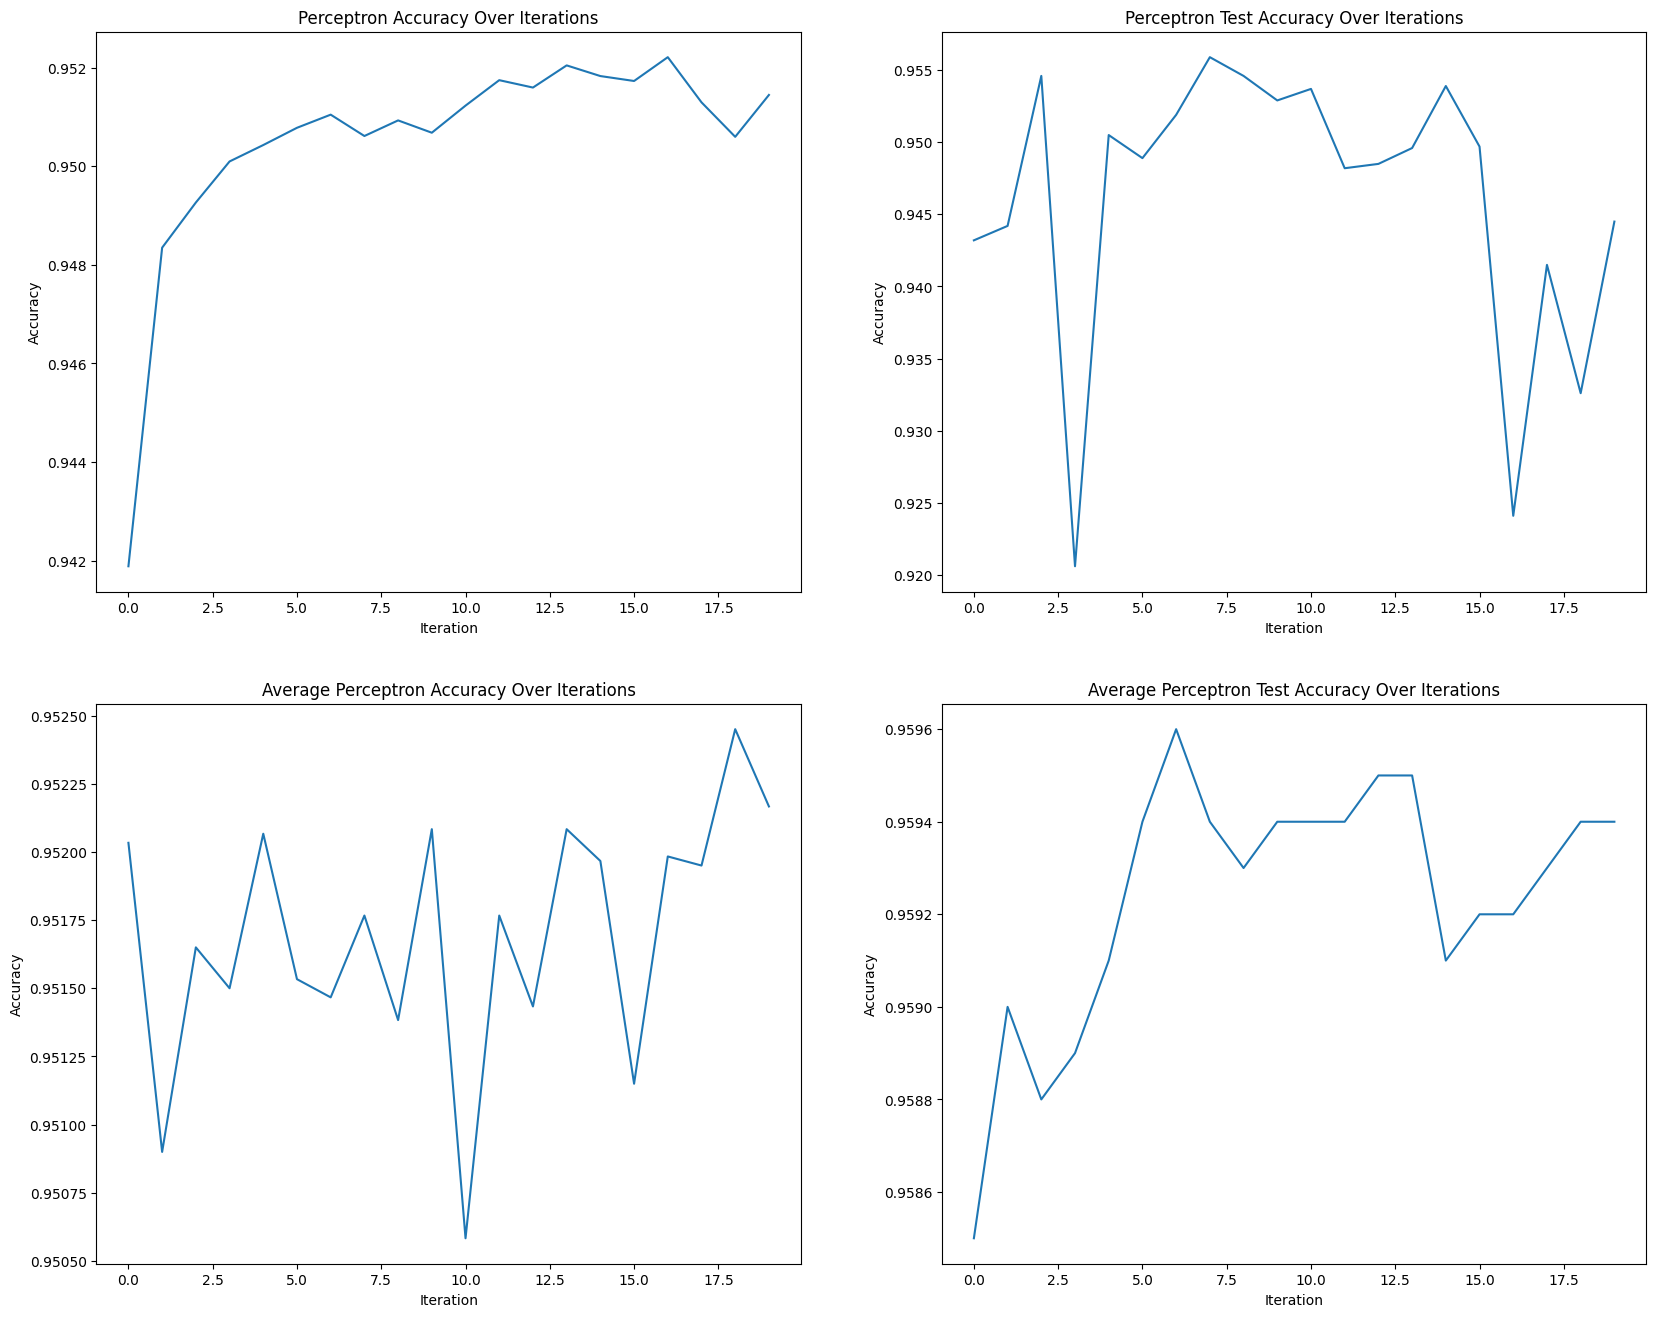

In [15]:
## Perceptron Algorithm Implementation
w = np.zeros(train_data[0].shape[0], dtype=np.float32)

T = 20  # Number of iterations for the main loop
perceptron_train_accuracy = {}
perceptron_test_accuracy = {}
def return_label(label: int) -> int:
    return 1 if label % 2 != 0 else -1

def test_accuracy(w):
    perceptron_test_accuracy = 0
    for td, tl in zip(eval_data, eval_labels):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred == y_true:
            perceptron_test_accuracy += 1
    return  perceptron_test_accuracy / len(eval_data)

# 2- main loop
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred != y_true:
            w += y_true * td
        else:
            if i not in perceptron_train_accuracy:
                perceptron_train_accuracy[i] = 0
            perceptron_train_accuracy[i] += 1
    perceptron_train_accuracy[i] = perceptron_train_accuracy[i] / len(train_data)
    perceptron_test_accuracy[i] = test_accuracy(w)


## average perceptron Algorithm Implementation
average_perceptron_train_accuracy = {}
average_perceptron_test_accuracy = {}
def return_label(label: int) -> int:
    return 1 if label % 2 != 0 else -1

def test_accuracy(w):
    perceptron_test_accuracy = 0
    for td, tl in zip(eval_data, eval_labels):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred == y_true:
            perceptron_test_accuracy += 1
    return  perceptron_test_accuracy / len(eval_data)

# 2- main loop
avg_weights = np.zeros(train_data[0].shape[0], dtype=np.float32)
vector_weight = 1
for i in range(T):
    correct = 0
    for td, tl in zip(train_data, train_labels):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred != y_true:
            w += y_true * td
            avg_weights += vector_weight * y_true * td
        else:
            correct += 1
            if i not in average_perceptron_train_accuracy:
                average_perceptron_train_accuracy[i] = 0
            average_perceptron_train_accuracy[i] += 1
        vector_weight += 1
    w_avg = w - avg_weights / vector_weight
    average_perceptron_train_accuracy[i] = correct / len(train_data)
    average_perceptron_test_accuracy[i] = test_accuracy(w_avg)

import matplotlib.pyplot as plt
%matplotlib inline
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
max_y = max(list(perceptron_train_accuracy.values()) + list(average_perceptron_train_accuracy.values()))
min_y = min(list(perceptron_train_accuracy.values()) + list(average_perceptron_train_accuracy.values()))
ax1.plot(perceptron_train_accuracy.keys(), perceptron_train_accuracy.values())
#ax1.set_ylim(min_y, max_y)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Accuracy')
ax1.set_title('Perceptron Accuracy Over Iterations')

ax2.plot(perceptron_test_accuracy.keys(), perceptron_test_accuracy.values())
#ax2.set_ylim(min_y, max_y)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Accuracy')
ax2.set_title('Perceptron Test Accuracy Over Iterations')

ax3.plot(average_perceptron_train_accuracy.keys(), average_perceptron_train_accuracy.values())
#ax3.set_ylim(min_y, max_y)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Accuracy')
ax3.set_title('Average Perceptron Accuracy Over Iterations')

ax4.plot(list(average_perceptron_test_accuracy.keys()), list(average_perceptron_test_accuracy.values()))
#ax4.set_ylim(0.94, 0.98)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Accuracy')
ax4.set_title('Average Perceptron Test Accuracy Over Iterations')

plt.show()

Analysis:

D)

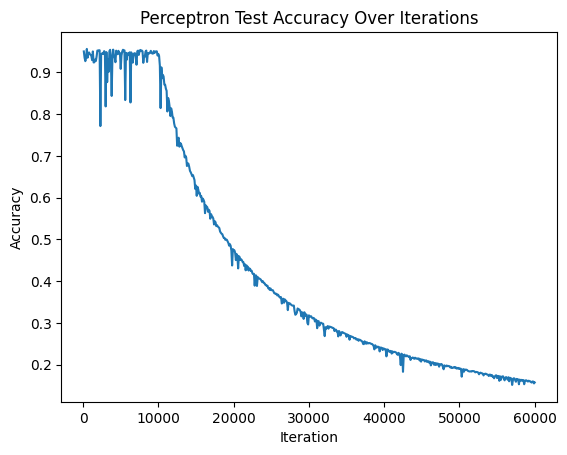

In [36]:
T = 20  # Number of iterations for the main loop
perceptron_test_accuracy = {}
def return_label(label: int) -> int:
    return 1 if label % 2 != 0 else -1

def test_accuracy(w, i):
    perceptron_test_accuracy = 0
    for td, tl in zip(eval_data[:i], eval_labels[:i]):
        y_true = return_label(tl)
        theta_x = np.sign(np.dot(w, td))
        y_pred = theta_x if theta_x != 0 else -1
        if y_pred == y_true:
            perceptron_test_accuracy += 1
    return  perceptron_test_accuracy / i

# 2- main loop
for i in range(100, len(train_data) + 1, 100):
    w = np.zeros(train_data[0].shape[0], dtype=np.float32)
    for _ in range(T):
        for td, tl in zip(train_data[:i], train_labels[:i]):
            y_true = return_label(tl)
            theta_x = np.sign(np.dot(w, td))
            y_pred = theta_x if theta_x != 0 else -1
            if y_pred != y_true:
                w += y_true * td
    perceptron_test_accuracy[i] = test_accuracy(w, i)

plt.plot(perceptron_test_accuracy.keys(), perceptron_test_accuracy.values())
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Perceptron Test Accuracy Over Iterations')
plt.show()

Analysis

## Multi-class Classification model using Perceptron

In [12]:
# 1- Initialize the weight matrix
k = 10
w = np.zeros((k, train_data[0].shape[0]), dtype=np.float32)
T = 100  # Number of iterations for the main loop
perceptron_mistakes = {}

# 2- main loop
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        theta_x = np.dot(w, td)
        y_pred = int(np.argmax(theta_x))
        if y_pred != tl:
            w[y_pred] -= td
            w[tl] += td
            if i not in perceptron_mistakes:
                perceptron_mistakes[i] = 0
            perceptron_mistakes[i] += 1

## Multi-class Classification model using PA algorithm

In [ ]:
k = 10
w = np.zeros((k, train_data[0].shape[0]), dtype=np.float32)
T = 100  # Number of iterations for the main loop
pa_mistakes = {}

# 2- main loop
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        theta_x = np.dot(w, td)
        y_pred = int(np.argmax(theta_x))
        if y_pred != tl:
            tau = (1 - theta_x[tl] - theta_x[y_pred]) / (2 * (np.linalg.norm(tl - y_pred) ** 2))
            w[y_pred] -= tau * td
            w[tl] += tau * td
            if i not in pa_mistakes:
                pa_mistakes[i] = 0
            pa_mistakes[i] += 1

## Plot the mistakes

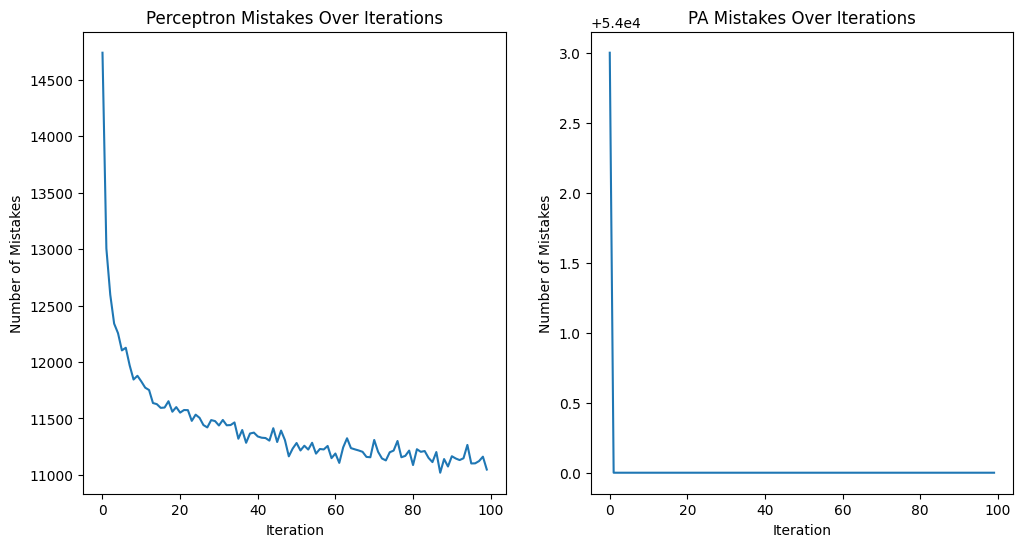

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
max_y = max(list(perceptron_mistakes.values()) + list(pa_mistakes.values()))
min_y = min(list(perceptron_mistakes.values()) + list(pa_mistakes.values()))
ax1.plot(perceptron_mistakes.keys(), perceptron_mistakes.values())
#ax1.set_ylim(min_y, max_y)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Number of Mistakes')
ax1.set_title('Perceptron Mistakes Over Iterations')

ax2.plot(pa_mistakes.keys(), pa_mistakes.values())
#ax2.set_ylim(min_y, max_y)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Number of Mistakes')
ax2.set_title('PA Mistakes Over Iterations')

plt.show()

b)



/var/folders/bp/f5j1dx0d3l127lm179v0_zkr0000gn/T/ipykernel_2524/4180199409.py:44: RuntimeWarning: invalid value encountered in multiply
  w[y_pred] -= tau * td
/var/folders/bp/f5j1dx0d3l127lm179v0_zkr0000gn/T/ipykernel_2524/4180199409.py:45: RuntimeWarning: invalid value encountered in multiply
  w[tl] += tau * td


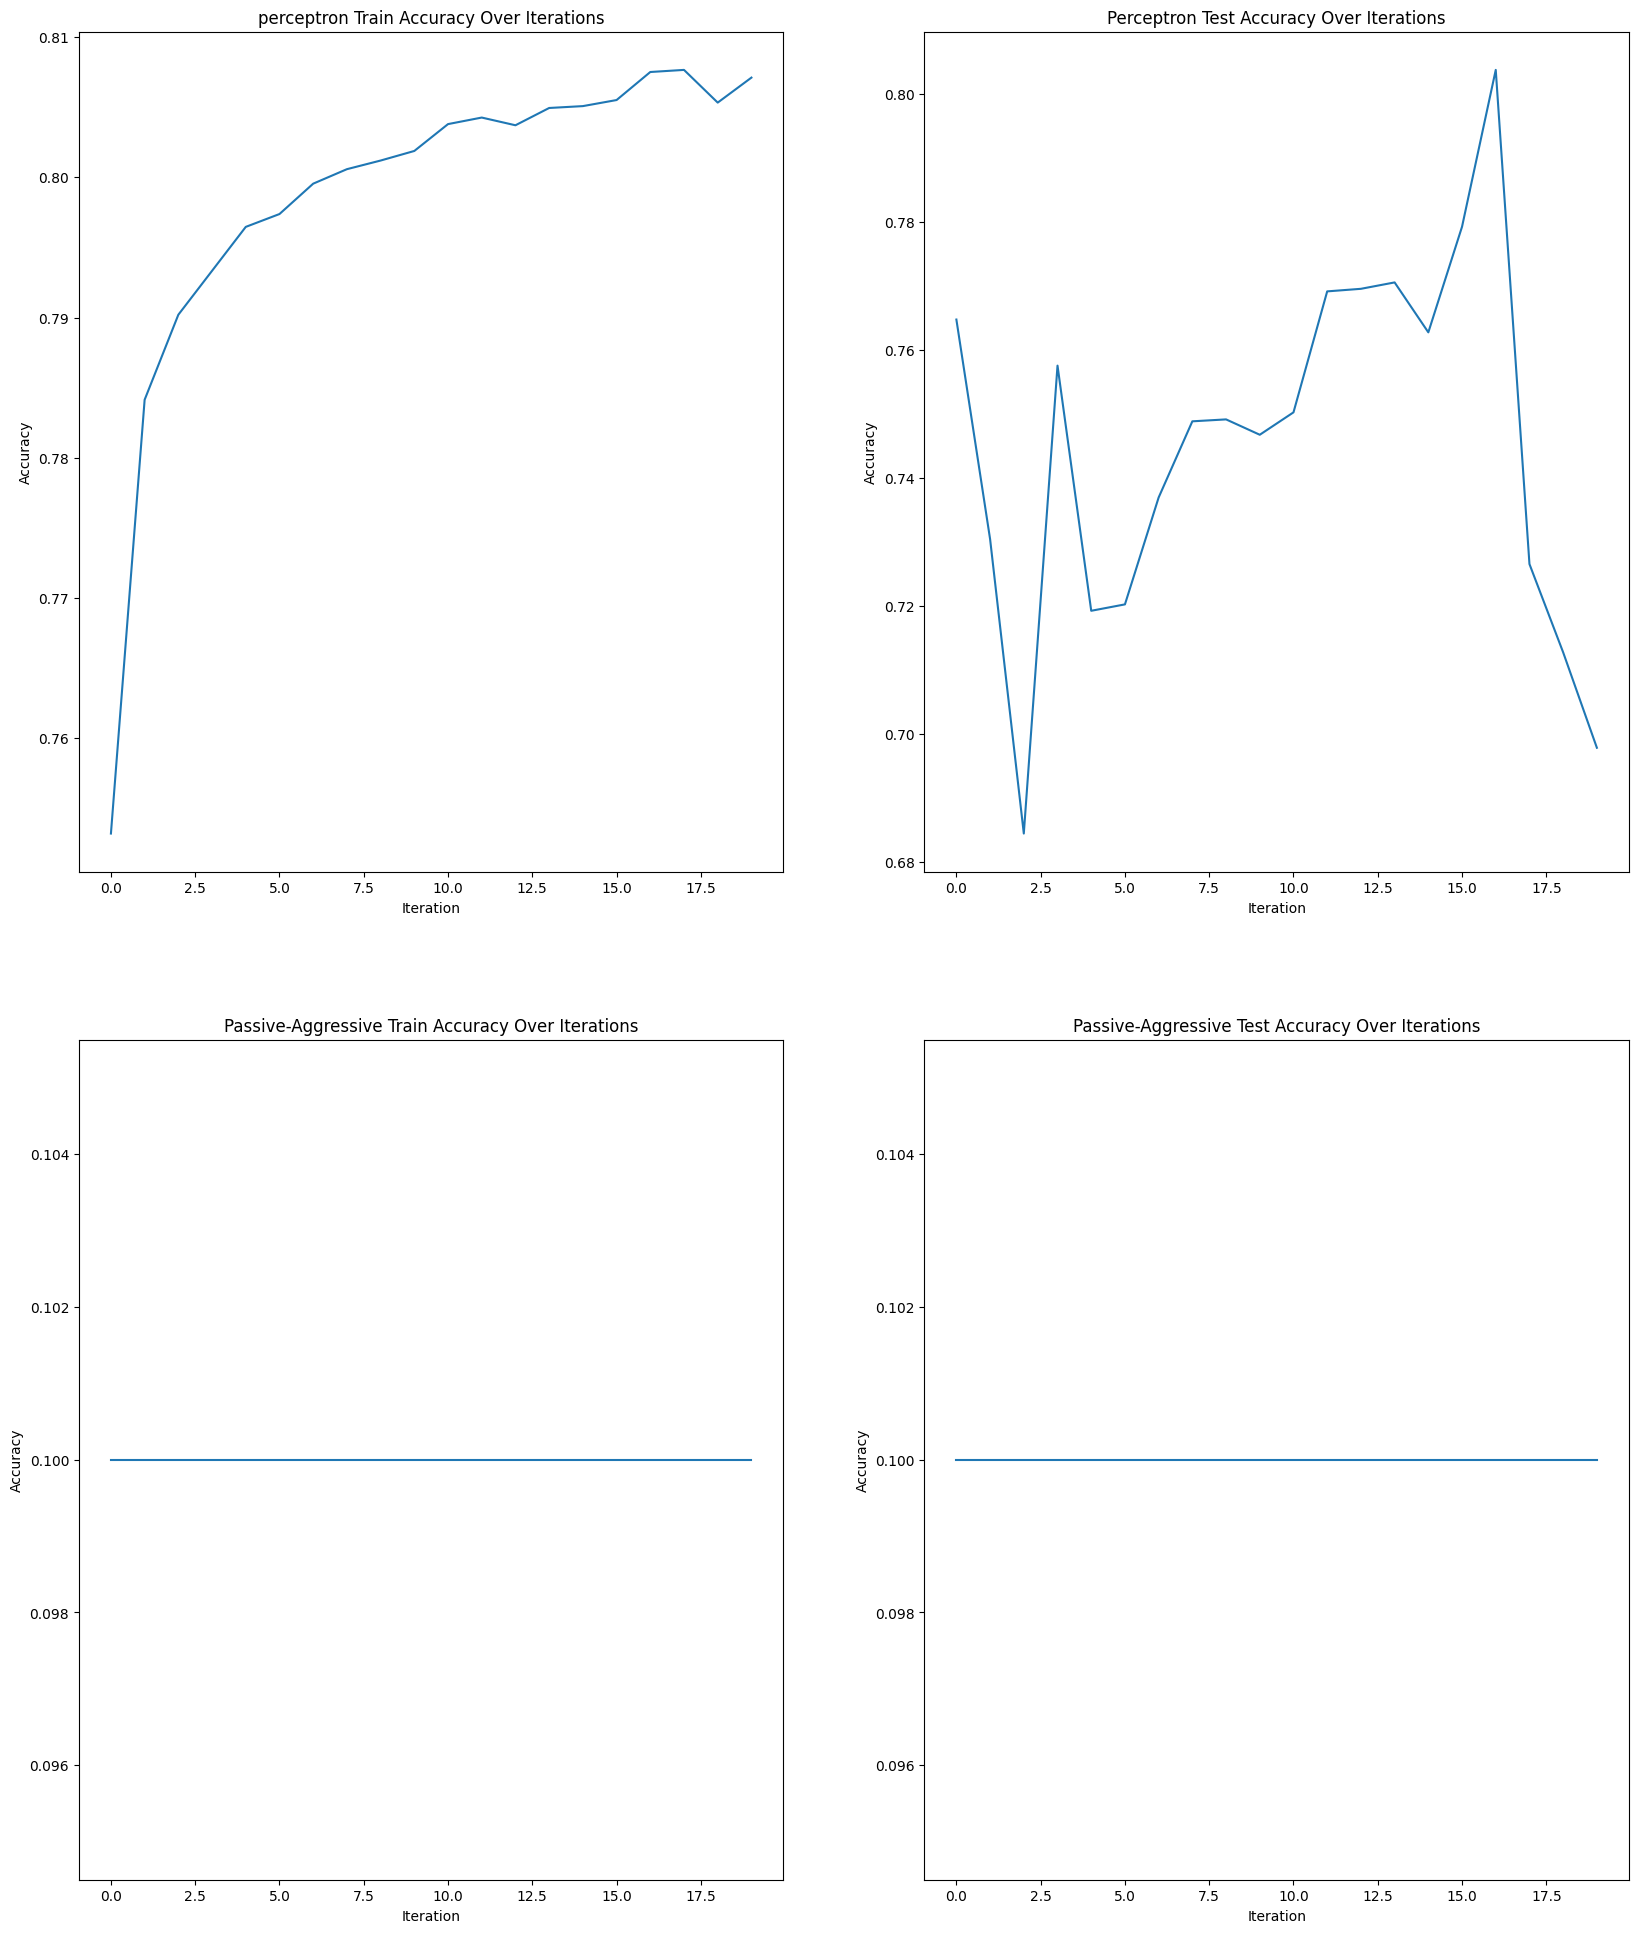

In [26]:
k = 10
T = 20  # Number of iterations for the main loop

def test_accuracy(w):
    perceptron_test_accuracy = 0
    for td, tl in zip(eval_data, eval_labels):
        y_true = tl
        y_pred = int(np.argmax(np.dot(w, td)))
        if y_pred == y_true:
            perceptron_test_accuracy += 1
    return  perceptron_test_accuracy / len(eval_data)

# Perceptron algorithm
perceptron_train_accuracy = {}
perceptron_test_accuracy = {}
# 2- main loop
w = np.zeros((k, train_data[0].shape[0]), dtype=np.float32)
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        theta_x = np.dot(w, td)
        y_pred = int(np.argmax(theta_x))
        if y_pred != tl:
            w[tl] += td
            w[y_pred] -= td
        else:
            if i not in perceptron_train_accuracy.keys():
                perceptron_train_accuracy[i] = 0
            perceptron_train_accuracy[i] += 1
    perceptron_train_accuracy[i] /= len(train_data)
    perceptron_test_accuracy[i] = test_accuracy(w)


# Passive-Aggressive algorithm
pa_train_accuracy = {}
pa_test_accuracy = {}
# 2- main loop
w = np.zeros((k, train_data[0].shape[0]), dtype=np.float32)
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        theta_x = np.dot(w, td)
        y_pred = int(np.argmax(theta_x))
        if y_pred != tl:
            tau = (1 - theta_x[tl] - theta_x[y_pred]) / (2 * (np.linalg.norm(tl - y_pred) ** 2))
            w[y_pred] -= tau * td
            w[tl] += tau * td
        else:
            if i not in pa_train_accuracy.keys():
                pa_train_accuracy[i] = 0
            pa_train_accuracy[i] += 1
    pa_train_accuracy[i] /= len(train_data)
    pa_test_accuracy[i] = test_accuracy(w)

import matplotlib.pyplot as plt
%matplotlib inline
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 24))
ax1.plot(perceptron_train_accuracy.keys(), perceptron_train_accuracy.values())
#ax1.set_ylim(min_y, max_y)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Accuracy')
ax1.set_title('perceptron Train Accuracy Over Iterations')

ax2.plot(perceptron_test_accuracy.keys(), perceptron_test_accuracy.values())
#ax1.set_ylim(min_y, max_y)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Accuracy')
ax2.set_title('Perceptron Test Accuracy Over Iterations')

ax3.plot(pa_train_accuracy.keys(), pa_train_accuracy.values())
#ax2.set_ylim(min_y, max_y)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Accuracy')
ax3.set_title('Passive-Aggressive Train Accuracy Over Iterations')

ax4.plot(pa_test_accuracy.keys(), pa_test_accuracy.values())
#ax3.set_ylim(min_y, max_y)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Accuracy')
ax4.set_title('Passive-Aggressive Test Accuracy Over Iterations')

plt.show()

C)

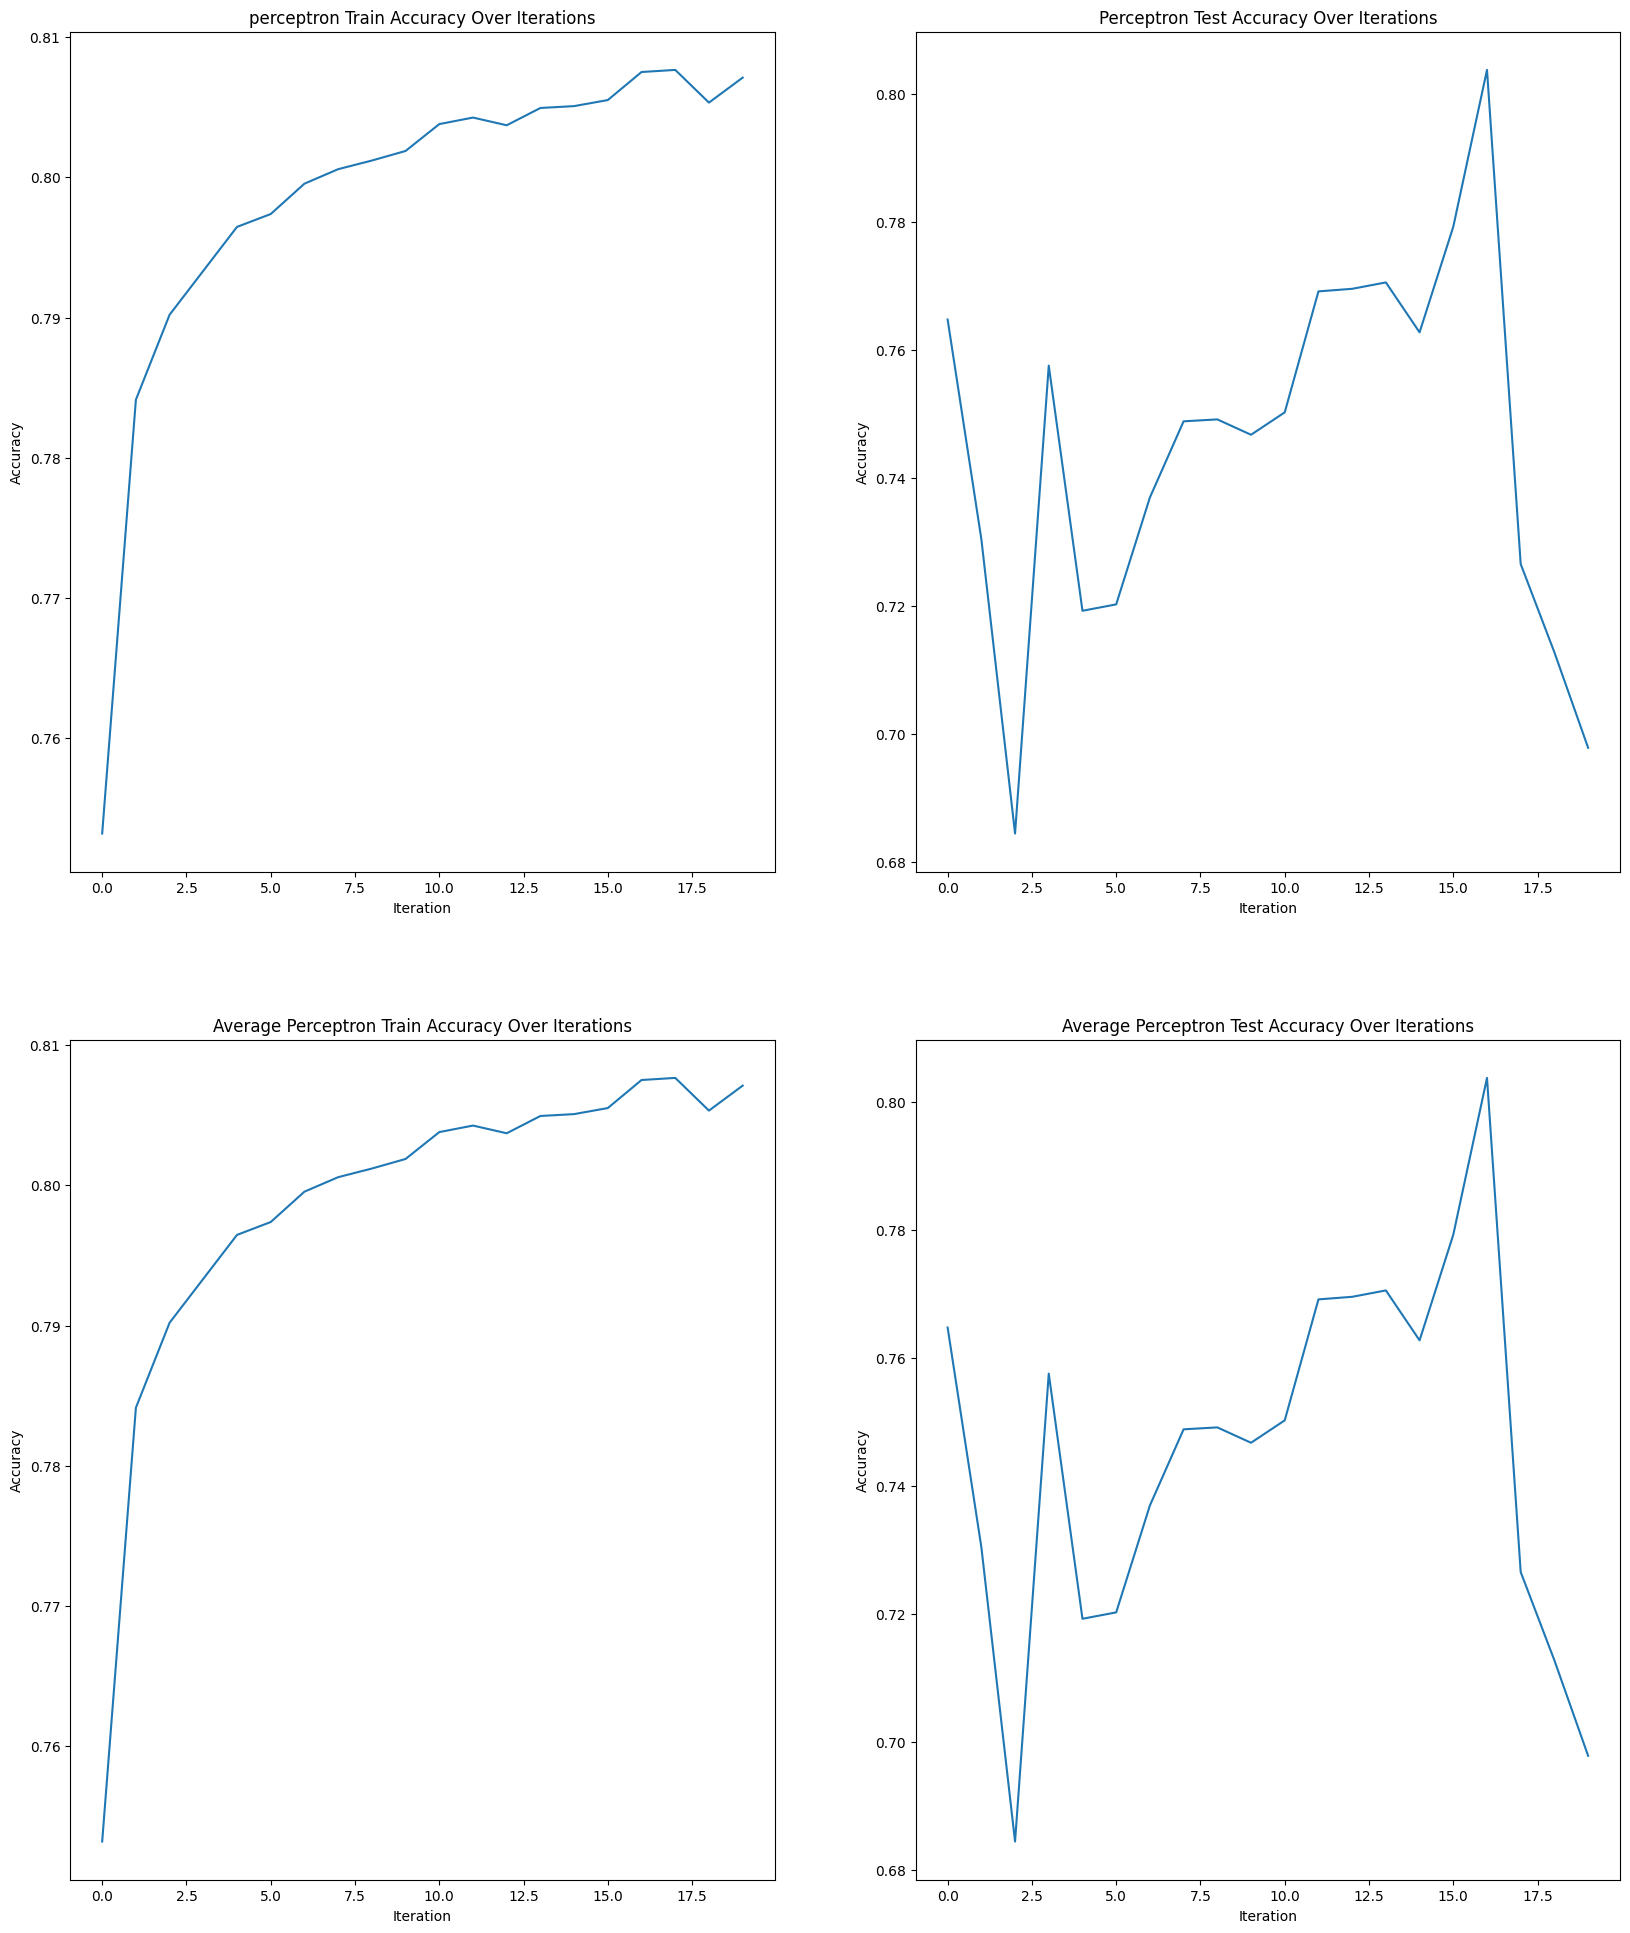

In [29]:
k = 10
T = 20  # Number of iterations for the main loop

def test_accuracy(w):
    perceptron_test_accuracy = 0
    for td, tl in zip(eval_data, eval_labels):
        y_true = tl
        y_pred = int(np.argmax(np.dot(w, td)))
        if y_pred == y_true:
            perceptron_test_accuracy += 1
    return  perceptron_test_accuracy / len(eval_data)

# Perceptron algorithm
perceptron_train_accuracy = {}
perceptron_test_accuracy = {}
# 2- main loop
w = np.zeros((k, train_data[0].shape[0]), dtype=np.float32)
for i in range(T):
    for td, tl in zip(train_data, train_labels):
        theta_x = np.dot(w, td)
        y_pred = int(np.argmax(theta_x))
        if y_pred != tl:
            w[tl] += td
            w[y_pred] -= td
        else:
            if i not in perceptron_train_accuracy.keys():
                perceptron_train_accuracy[i] = 0
            perceptron_train_accuracy[i] += 1
    perceptron_train_accuracy[i] /= len(train_data)
    perceptron_test_accuracy[i] = test_accuracy(w)


# average Perceptron algorithm
average_perceptron_train_accuracy = {}
average_perceptron_test_accuracy = {}
# 2- main loop
w = np.zeros((k, train_data[0].shape[0]), dtype=np.float32)
w_a = np.zeros((k, train_data[0].shape[0]), dtype=np.float32)
c = 1
for i in range(T):
    correct = 0
    for td, tl in zip(train_data, train_labels):
        theta_x = np.dot(w, td)
        y_pred = int(np.argmax(theta_x))
        if y_pred != tl:
            w[tl] += td
            w[y_pred] -= td
            w_a[tl]     += c * td
            w_a[y_pred] -= c * td
        else:
            correct += 1
            if i not in average_perceptron_train_accuracy.keys():
                average_perceptron_train_accuracy[i] = 0
            average_perceptron_train_accuracy[i] += 1
    average_perceptron_train_accuracy[i] /= len(train_data)
    average_perceptron_test_accuracy[i] = test_accuracy(w)

import matplotlib.pyplot as plt
%matplotlib inline
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 24))
ax1.plot(perceptron_train_accuracy.keys(), perceptron_train_accuracy.values())
#ax1.set_ylim(min_y, max_y)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Accuracy')
ax1.set_title('perceptron Train Accuracy Over Iterations')

ax2.plot(perceptron_test_accuracy.keys(), perceptron_test_accuracy.values())
#ax1.set_ylim(min_y, max_y)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Accuracy')
ax2.set_title('Perceptron Test Accuracy Over Iterations')

ax3.plot(average_perceptron_train_accuracy.keys(), average_perceptron_train_accuracy.values())
#ax2.set_ylim(min_y, max_y)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Accuracy')
ax3.set_title('Average Perceptron Train Accuracy Over Iterations')

ax4.plot(average_perceptron_test_accuracy.keys(), average_perceptron_test_accuracy.values())
#ax3.set_ylim(min_y, max_y)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Accuracy')
ax4.set_title('Average Perceptron Test Accuracy Over Iterations')

plt.show()

D)

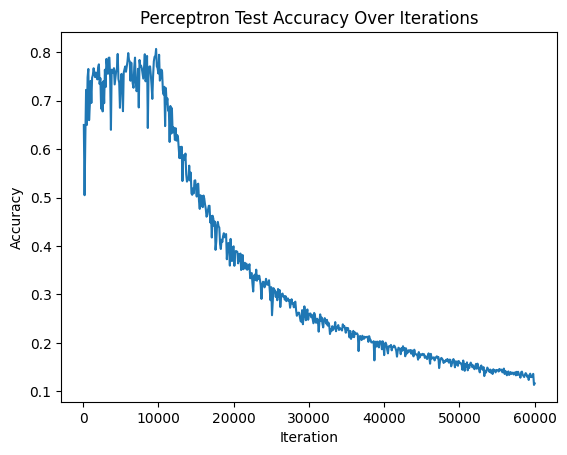

In [33]:
k = 10
T = 20
def test_accuracy(w, i):
    perceptron_test_accuracy = 0
    for td, tl in zip(eval_data[:i], eval_labels[:i]):
        y_true = tl
        y_pred = int(np.argmax(np.dot(w, td)))
        if y_pred == y_true:
            perceptron_test_accuracy += 1
    return  perceptron_test_accuracy / i

# Perceptron algorithm
perceptron_test_accuracy = {}
for i in range(100, len(train_data) + 1, 100):
    w = np.zeros((k, train_data[0].shape[0]), dtype=np.float32)
    for _ in range(T):
        for td, tl in zip(train_data[:i], train_labels[:i]):
            theta_x = np.dot(w, td)
            y_pred = int(np.argmax(theta_x))
            if y_pred != tl:
                w[tl] += td
                w[y_pred] -= td
    perceptron_test_accuracy[i] = test_accuracy(w, i)

plt.plot(perceptron_test_accuracy.keys(), perceptron_test_accuracy.values())
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Perceptron Test Accuracy Over Iterations')
plt.show()